<a href="https://colab.research.google.com/github/ramneeth/HousingSalePriceProject/blob/main/HousingSalePrice_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Housing Sale Price Predictive Model**

Ramneet Hunjan

April 18, 2025

## **Data Handeling and Exploration**

In [ ]:
import pandas as pd
import copy
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score,mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

I start by getting an idea of the information available in the .csv file. More importantly what features are avaialble that could be used to predict house sale price.

At first glance I notice NaN (Not a Number) values in columns like 'Alley' and 'GarageType' so these values will need to be filtered out as well.

In my opinion it seems as though all other features are relevant in predicting our target value, 'SalePrice', but I will do some more exploratory analysis before making any conclusions about which features to keep for training.

In [ ]:
df = pd.read_csv('dataset.csv')
df.head()

,LotArea,GrLivArea,Street,Alley,LotType,BldgType,HouseStyle,OverallQuality,OverallCondition,YearBuilt,...,CentralAir,FullBath,HalfBath,GarageType,GarageCars,GarageArea,YearSold,SaleType,SaleCondition,SalePrice
0,8910,1194,Pave,NaN,Corner,1Fam,1Fam,6,6,1959,...,Y,1,0,BuiltIn,2,539.0,2006,WD,Normal,159500
1,1526,630,Pave,NaN,Inside,Twnhs,SFoyer,4,8,1970,...,Y,1,0,Attchd,1,286.0,2009,WD,Normal,86000
2,14598,1933,Pave,NaN,CulDSac,1Fam,2Story,6,5,2007,...,Y,2,1,BuiltIn,3,668.0,2008,WD,Normal,214000
3,7200,1040,Pave,NaN,Inside,Duplex,1Story,4,5,1949,...,N,2,0,Detchd,2,420.0,2009,WD,Normal,90000
4,5687,1716,Pave,Grvl,Inside,2fmCon,2Story,5,6,1912,...,N,2,0,NaN,0,0.0,2008,WD,Normal,135900


I would also like to explore what the SalePrice data looks like, and what its distribution is to ensure the best model is chosen for its predictions.

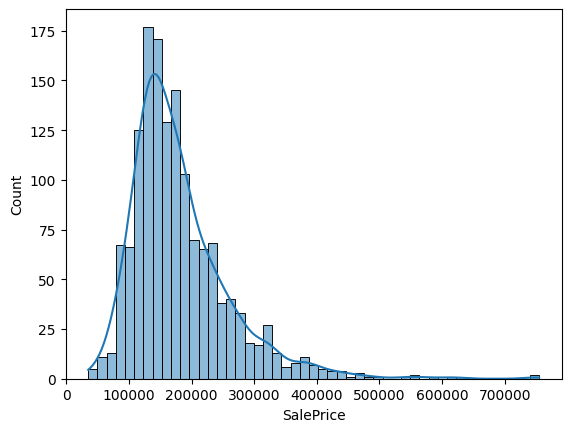

In [ ]:
sns.histplot(df['SalePrice'], kde=True)
plt.show()


It seems like the SalePrice data is right skewed. This indicates that something like a simple Linear Regression model may not be the *best* option here. Instead, it may require regularization techniques like Ridge or LASSO regression or even a model like RandomForestRegressor which does a better job at capturing non-linear relationships. We will try all of these options to confirm my theory.

In [ ]:
df.describe()

,LotArea,GrLivArea,OverallQuality,OverallCondition,YearBuilt,TotalBsmtSF,FullBath,HalfBath,GarageCars,GarageArea,YearSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1417.000000,1460.000000,1460.000000
mean,10516.828082,1567.207534,6.099315,5.575342,1971.267808,1057.429452,1.565068,0.382877,1.767123,471.409315,2007.815753,180921.195890
std,9981.264932,1072.198454,1.382997,1.112799,30.202904,438.705324,0.550916,0.502885,0.747315,214.217863,1.328095,79442.502883
min,1300.000000,334.000000,1.000000,1.000000,1872.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2006.000000,34900.000000
25%,7553.500000,1130.750000,5.000000,5.000000,1954.000000,795.750000,1.000000,0.000000,1.000000,326.000000,2007.000000,129975.000000
50%,9478.500000,1466.000000,6.000000,5.000000,1973.000000,991.500000,2.000000,0.000000,2.000000,478.000000,2008.000000,163000.000000
75%,11601.500000,1784.500000,7.000000,6.000000,2000.000000,1298.250000,2.000000,1.000000,2.000000,576.000000,2009.000000,214000.000000
max,215245.000000,23400.000000,10.000000,9.000000,2010.000000,6110.000000,3.000000,2.000000,4.000000,1418.000000,2010.000000,755000.000000


Create a Correlation Heatmap to possibly help identify important features for feature selection later

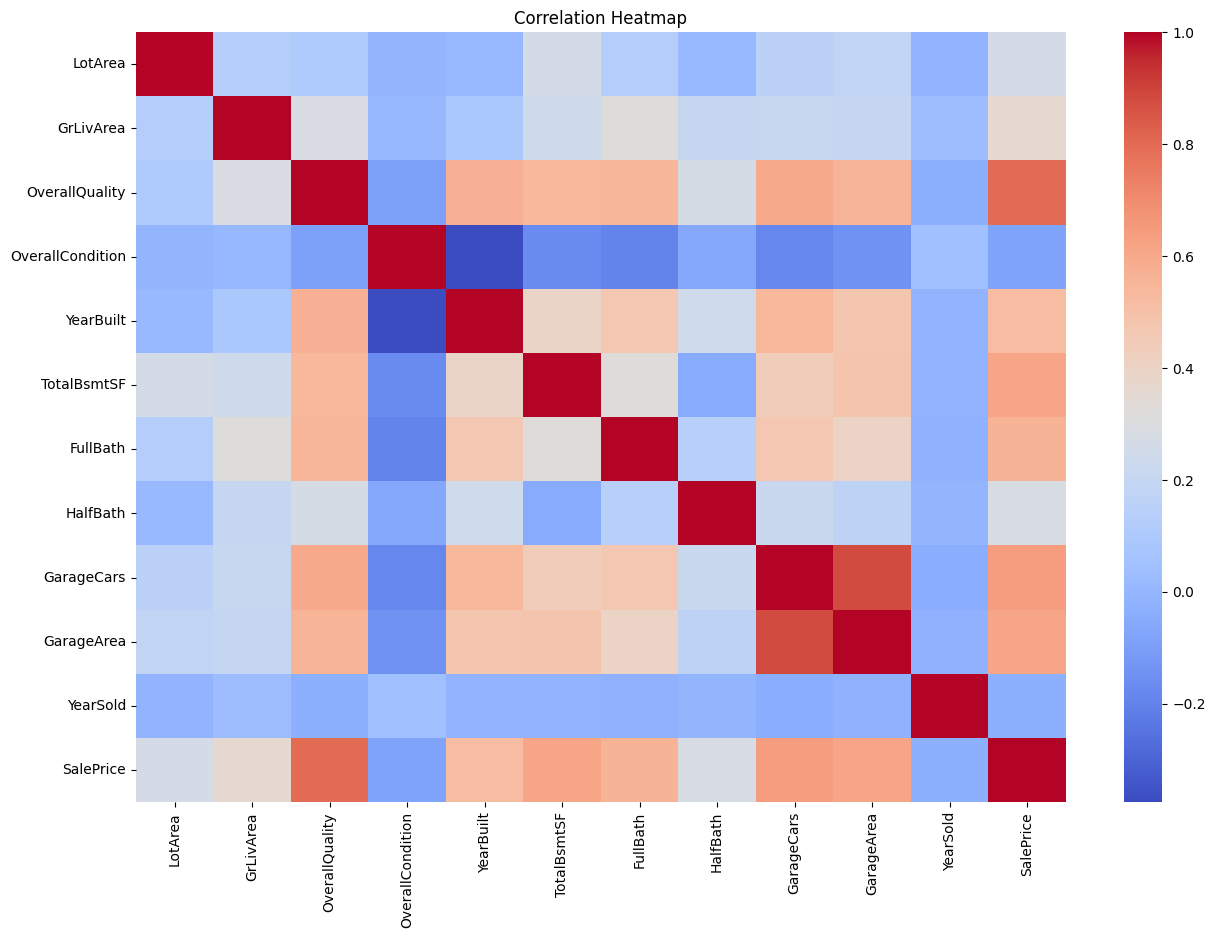

In [ ]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()


Based on the heat map, it seems like the features most correlated with SalePrice are OverallQuality, YearBuilt, TotalBsmtSF, FullBath, GarageCars, and GarageArea.

These features will likely be included in the model as they may give us better results when trying to predict SalePrice.

Now, I will check to see if any values are missing from the dataset.

In [ ]:
#check for missing values
print('Number of Missing Values per Column: \n', df.isnull().sum())

Number of Missing Values per Column: 
 LotArea                0
GrLivArea              0
Street                 0
Alley               1369
LotType                0
BldgType               0
HouseStyle             0
OverallQuality         0
OverallCondition       0
YearBuilt              0
Foundation             0
TotalBsmtSF            0
CentralAir             0
FullBath               0
HalfBath               0
GarageType            81
GarageCars             0
GarageArea            43
YearSold               0
SaleType               0
SaleCondition          0
SalePrice              0
dtype: int64


Now, we filter out the NaN and missing values mentioned earlier

In [ ]:
df['Alley'].fillna('None', inplace=True)

df['GarageType'].fillna('None', inplace=True)

df['GarageArea'].fillna(0, inplace=True)

<ipython-input-7-a19fbf08475e>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Alley'].fillna('None', inplace=True)
<ipython-input-7-a19fbf08475e>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.meth

The foundation column also has entries like "Do Not use this Field in the Model" that need to be taken care of

In [ ]:
df = df[df['Foundation'] != 'Do Not use this Field in the Model']

Now we check again to see if those values were removed, just to be safe

In [ ]:
df.head()

,LotArea,GrLivArea,Street,Alley,LotType,BldgType,HouseStyle,OverallQuality,OverallCondition,YearBuilt,...,CentralAir,FullBath,HalfBath,GarageType,GarageCars,GarageArea,YearSold,SaleType,SaleCondition,SalePrice
0,8910,1194,Pave,None,Corner,1Fam,1Fam,6,6,1959,...,Y,1,0,BuiltIn,2,539.0,2006,WD,Normal,159500
1,1526,630,Pave,None,Inside,Twnhs,SFoyer,4,8,1970,...,Y,1,0,Attchd,1,286.0,2009,WD,Normal,86000
2,14598,1933,Pave,None,CulDSac,1Fam,2Story,6,5,2007,...,Y,2,1,BuiltIn,3,668.0,2008,WD,Normal,214000
3,7200,1040,Pave,None,Inside,Duplex,1Story,4,5,1949,...,N,2,0,Detchd,2,420.0,2009,WD,Normal,90000
4,5687,1716,Pave,Grvl,Inside,2fmCon,2Story,5,6,1912,...,N,2,0,None,0,0.0,2008,WD,Normal,135900


In [ ]:
df.head()

#check for missing values
print('Number of Missing Values per Column: \n', df.isnull().sum())

Number of Missing Values per Column: 
 LotArea             0
GrLivArea           0
Street              0
Alley               0
LotType             0
BldgType            0
HouseStyle          0
OverallQuality      0
OverallCondition    0
YearBuilt           0
Foundation          0
TotalBsmtSF         0
CentralAir          0
FullBath            0
HalfBath            0
GarageType          0
GarageCars          0
GarageArea          0
YearSold            0
SaleType            0
SaleCondition       0
SalePrice           0
dtype: int64


In [ ]:
df.head()

,LotArea,GrLivArea,Street,Alley,LotType,BldgType,HouseStyle,OverallQuality,OverallCondition,YearBuilt,...,CentralAir,FullBath,HalfBath,GarageType,GarageCars,GarageArea,YearSold,SaleType,SaleCondition,SalePrice
0,8910,1194,Pave,None,Corner,1Fam,1Fam,6,6,1959,...,Y,1,0,BuiltIn,2,539.0,2006,WD,Normal,159500
1,1526,630,Pave,None,Inside,Twnhs,SFoyer,4,8,1970,...,Y,1,0,Attchd,1,286.0,2009,WD,Normal,86000
2,14598,1933,Pave,None,CulDSac,1Fam,2Story,6,5,2007,...,Y,2,1,BuiltIn,3,668.0,2008,WD,Normal,214000
3,7200,1040,Pave,None,Inside,Duplex,1Story,4,5,1949,...,N,2,0,Detchd,2,420.0,2009,WD,Normal,90000
4,5687,1716,Pave,Grvl,Inside,2fmCon,2Story,5,6,1912,...,N,2,0,None,0,0.0,2008,WD,Normal,135900


Looks good!

As one final preprocessing step before we assign features and the target, I will also encode categorical values.

Categorical variables with only two possible values will be encoded using a binary system of either 0 or 1.

Categorical variables with more than two possible values will be encoded using one-hot encoding, creating new binary columns for each possible value.

In [ ]:
# encode central air as binary 0 or 1
df['CentralAir'] = df['CentralAir'].map({'N': 0, 'Y': 1})

# encode street as binary 0 or 1
df['Street'] = df['Street'].map({'Grvl': 0, 'Pave': 1})

# One-hot encode selected columns
df = pd.get_dummies(df, columns=[
    'Alley', 'LotType', 'BldgType', 'HouseStyle',
    'Foundation', 'GarageType', 'SaleType', 'SaleCondition'
], drop_first=True)


In [ ]:
df.head()

,LotArea,GrLivArea,Street,OverallQuality,OverallCondition,YearBuilt,TotalBsmtSF,CentralAir,FullBath,HalfBath,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,SaleCondition_normal
0,8910,1194,1,6,6,1959,655,1,1,0,...,False,False,False,True,False,False,False,True,False,False
1,1526,630,1,4,8,1970,630,1,1,0,...,False,False,False,True,False,False,False,True,False,False
2,14598,1933,1,6,5,2007,894,1,2,1,...,False,False,False,True,False,False,False,True,False,False
3,7200,1040,1,4,5,1949,0,0,2,0,...,False,False,False,True,False,False,False,True,False,False
4,5687,1716,1,5,6,1912,780,0,2,0,...,False,False,False,True,False,False,False,True,False,False


## **Feature Engineering:**

I used mutual info regression to identify the top 10 MI features. MI features tell us how much each feature reduces uncertainty in the SalePrice, so ideally we would choose the features that reduce uncertainty of the SalePrice the *most*. I chose this instead of correlation to account for nonlinearity and because the data contains multiple categorical variables.

In [ ]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

mi = mutual_info_regression(X, y)
mi_series = pd.Series(mi, index=X.columns)
mi_series = mi_series.sort_values(ascending=False)

#top 10 features
print("Top 10 MI features:")
print(mi_series.head(10))


Top 10 MI features:
OverallQuality       0.566087
GrLivArea            0.446327
TotalBsmtSF          0.379506
YearBuilt            0.377192
GarageCars           0.368460
GarageArea           0.344999
FullBath             0.254694
Foundation_PConc     0.195062
LotArea              0.157568
GarageType_Attchd    0.125703
dtype: float64


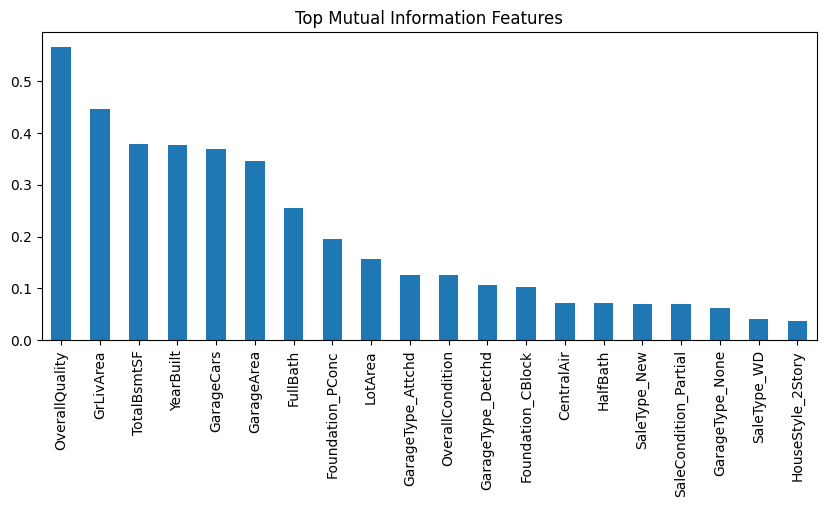

In [ ]:
mi_series.head(20).plot(kind='bar', figsize=(10, 4), title='Top Mutual Information Features')
plt.show()


These results align quite well with our initial analysis using the correlation heat map as OverallQuality, YearBuilt, TotalBsmtSF, and GarageArea seem to still be highly related to SalePrice.

Based on the Top 10 MI features results and the plot above, we will use the Top 10 features for our model and ignore the rest for now.

Let's keep the top MI features and assign SalePrice as our target.

In [ ]:
X = df[["OverallQuality", "TotalBsmtSF", "GarageArea", "Alley_Pave", "YearBuilt", "GrLivArea", "BldgType_TwnhsE",
       "LotArea", "Foundation_PConc", "GarageType_Attchd"]]

y = df[["SalePrice"]]

## **Modelling/Evaluation:**

For the sake of comparison, I will add a baseline model (mean prediction, no learning), we will compare all following models to this baseline to understand if they are learning useful structure.

In [ ]:
baseline_prediction = [df["SalePrice"].mean()] * len(df)
baseline_rmse = np.sqrt(mean_squared_error(df["SalePrice"], baseline_prediction))
print("Baseline RMSE:", np.round(baseline_rmse, 2))

Baseline RMSE: 80290.62


Now, split the dataset into training and testing. We will set the test set size to 20% and the train set to 80%, by convention.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=101)



Try Linear Regression, as stated in the problem description, and use MSE and R^2 as a metric.

- **RMSE (Root Mean Squared Error)** gives the average prediction error in the same units as the target variable (`SalePrice` in dollars). It penalizes large errors more strongly.

- **R² (Coefficient of Determination)** measures how much of the variation in the target variable is explained by the model.

To evaluate each model’s ability to generalize and if there is any overfitting, we used 10-fold cross-validation. CV splits the training data into 10 parts, trains on 9, and validates on the 1 left out and repeats the process 10 times. This gives us a more reliable estimate of real-world performance by reducing variance due to any single data split, especially in small-to-medium datasets.

In [ ]:
#set up LR model

reg_model = LinearRegression().fit(X_train, y_train)

In [ ]:
y_pred = reg_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test RMSE:", np.round(rmse, 2))
r2 = r2_score(y_test, y_pred)
print("R² Score:", round(r2, 2))


scores = cross_val_score(reg_model, X_train, y_train, cv=10, scoring='r2')
print("10-Fold CV R²:", scores.mean())


Test RMSE: 37530.29
R² Score: 0.78
10-Fold CV R²: 0.6991478869746475


Linear Regression seems to be performing fine for a first attempt, but seems to be overfitting based on the CV score for R^2 so, for a usable model, let's try to get bettter.

To improve the linear regression model, lets try to implement a regularization technique like Ridge Regression

In [ ]:
ridge = Ridge(alpha=1.0)
ridge_model = ridge.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
print("Test RMSE:", np.round(rmse, 2))
r2 = r2_score(y_test, y_pred_ridge)
print("R² Score:", round(r2, 2))

scores = cross_val_score(ridge_model, X_train, y_train, cv=10, scoring='r2')
print("10-Fold CV R²:", scores.mean())

Test RMSE: 37520.14
R² Score: 0.78
10-Fold CV R²: 0.6991943456873352


It looks like using Ridge improved the RMSE, r^2 score, and the CV score, which mean better performance and less overfitting, but a CV score is still 0.699, so we will try to fix this. We can try hyperparameter tuning using GridSearch to determine the best alpha value. I chose GridSearch since we are only tuning one hyperparameter and it gives a thourough analysis of the best hyperparameters. If we had many hyperparameters, GridSearch may not be the best option since it would be much less efficient. Instead, a method like RandomSearch may be more appropriate, but instead would lack some of the thouroughness of the GridSearch method.

In [ ]:
ridge = Ridge()
params = {'alpha': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(ridge, params, scoring='r2', cv=5)
grid.fit(X_train, y_train)
print("Best alpha:", grid.best_params_)

Best alpha: {'alpha': 1}


Based on the results of the GridSearch it looks like alpha = 1 is the best value for the hyperparamether alpha, so there is no need to change anything for that hyperparameter.

Lets try LASSO now

In [ ]:
lasso = Lasso(alpha=1.0)
lasso_model = lasso.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
print("Test RMSE:", np.round(rmse, 2))
r2 = r2_score(y_test, y_pred_lasso)
print("R² Score:", round(r2, 2))

scores = cross_val_score(lasso_model, X_train, y_train, cv=10, scoring='r2')
print("10-Fold CV R²:", scores.mean())

Test RMSE: 37529.52
R² Score: 0.78
10-Fold CV R²: 0.699149760796794


Lets also try GridSearch for the LASSO model just to be sure.

In [ ]:
lasso = Lasso()
params = {'alpha': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(lasso, params, scoring='r2', cv=5)
grid.fit(X_train, y_train)
print("Best alpha:", grid.best_params_)

Best alpha: {'alpha': 10}


Looks like alpha = 10 is ideal for the LASSO model, so let's try that out.

In [ ]:
lasso = Lasso(alpha=10)
lasso_model = lasso.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
print("Test RMSE:", np.round(rmse, 2))
r2 = r2_score(y_test, y_pred_lasso)
print("R² Score:", round(r2, 2))

scores = cross_val_score(lasso_model, X_train, y_train, cv=10, scoring='r2')
print("10-Fold CV R²:", scores.mean())

Test RMSE: 37522.65
R² Score: 0.78
10-Fold CV R²: 0.6991655816205544


Looks like setting alpha = 10 for LASSO is relatively the same in all aspects.

Now, try Random Forest which, as stated above, due to the right skewedness of the SalePrice data, should perform better than the simple linear regression model.

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train.values.ravel())  # Flatten y if it's a DataFrame

y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("Random Forest Test RMSE:", np.round(rmse_rf, 2))
r2 = r2_score(y_test, y_pred_rf)
print("R² Score:", round(r2, 2))

scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
print("Average CV R²:", scores.mean())



Random Forest Test RMSE: 28059.59
R² Score: 0.88


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

Average CV R²: 0.8012237603031206


As suspected, the RandomForestRegression model performs the best!

## Conclusion

In [ ]:
#summary of model performance
results = pd.DataFrame({
    "Model": ["Baseline (Mean Prediction)", "Linear Regression", "Ridge Regression", "Lasso Regression", "Random Forest"],
    "Test RMSE": [80290.62, 37530.29, 37520.14, 37522.65, 28059.59],
    "Test R²": ['NA', 0.78, 0.78, 0.78, 0.88],
    "10-Fold CV R²": ['NA', 0.699, 0.699, 0.699, 0.801]
})

#display the table
results


,Model,Test RMSE,Test R²,10-Fold CV R²
0,Baseline (Mean Prediction),80290.62,NA,NA
1,Linear Regression,37530.29,0.78,0.699
2,Ridge Regression,37520.14,0.78,0.699
3,Lasso Regression,37522.65,0.78,0.699
4,Random Forest,28059.59,0.88,0.801


Based on the above results, for the linear regression models (includiing the regularized versions) performance was consistent accross all three methods, with no mothod doing significantly better than the other.

On the other hand, the Random Forest Regression model out performed all three linear models by decresing the RMSE, increasing the test R^2, AND improving the cross validation score. So overall it was able to improve model performance while reducing overfitting.

Despite extensive model tuning and testing, including linear regression, random forests, and regularized variants, the best cross-validation R² score achieved was ~0.80. This appears to stem from the limited number of predictive features in the dataset. Only a few variables, such as OverallQuality and GarageCars, exhibit strong correlation with SalePrice, while many others contribute little to model performance. Additionally, mild multicollinearity was observed between garage-related features. Still, the best model outperformed the baseline RMSE of 80,290.62 dollars, achieving a test RMSE near 28059.59 dollars, indicating that the model learned useful patterns despite limited signal.